# Data Preprocessing Pipeline
## RarePlanes + xView → Unified Aircraft Detection Dataset

**Pipeline overview:**
1. **RarePlanes** — convert oriented polygon annotations → axis-aligned bounding boxes; sample tiles across satellite images to reduce tile correlation
2. **xView** — filter to fixed-wing aircraft classes; tile large GeoTIFFs → 512×512 PNG patches; retain only aircraft-containing tiles
3. **Merge** — produce a unified COCO-format annotation file with a shared category taxonomy
4. **Balanced subset** — create a small, class-balanced subset for local training with a leakage-free train/val split

**Output layout:**
```
data_prep/output/
├── images/              # all 512×512 PNG tiles (rp_*.png, xv_*.png)
└── annotations/
    ├── dataset_full.json    # all preprocessed tiles
    ├── dataset_subset.json  # balanced subset
    ├── train.json
    └── val.json
```

**Unified category taxonomy:**

| id | name | RarePlanes source | xView source |
|---|---|---|---|
| 1 | `small_aircraft` | Small Civil Transport/Utility | Small Aircraft (12) |
| 2 | `medium_aircraft` | Medium Civil Transport/Utility | Fixed-wing Aircraft (11, 93) |
| 3 | `large_aircraft` | Large Civil Transport/Utility | Cargo Plane (13) |
| 4 | `military_aircraft` | Military Transport/Utility/AWAC | — |

In [1]:
# Install required packages if missing
import subprocess, sys

required = ['numpy', 'matplotlib', 'Pillow']
for pkg in required:
    mod = pkg.lower().replace('-', '_')
    try:
        __import__('PIL' if pkg == 'Pillow' else mod)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All dependencies available.')

All dependencies available.


In [2]:
import os
import json
import math
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('/Users/jonathan/Desktop/VoyagerTechnicalChallenge/Dataset')
RARE_DIR   = BASE_DIR / 'RarePlanes'
XVIEW_DIR  = BASE_DIR / 'xView'
OUT_DIR    = Path('/Users/jonathan/Desktop/VoyagerTechnicalChallenge/data_prep/output')
OUT_IMAGES = OUT_DIR / 'images'
OUT_ANNOTS = OUT_DIR / 'annotations'

# ── Preprocessing parameters ──────────────────────────────────────────────────
TILE_SIZE            = 512    # output tile size (pixels)
MIN_BBOX_AREA_PX     = 25     # drop bboxes smaller than this many pixels² (~5×5)

# RarePlanes
RP_MIN_PARTIAL_DEC   = 0.5    # drop annotations where < 50% of aircraft is visible
MAX_TILES_PER_CATID  = 20     # max tiles sampled per satellite image (cat_id)

# xView
XV_AIRCRAFT_IDS      = {11, 12, 13, 93}   # Fixed-wing, Small, Cargo, Fixed-wing variant
XV_MIN_OVERLAP_FRAC  = 0.25   # min fraction of annotation area that must fall inside a tile

# Subset / split
SEED                 = 42
SUBSET_SIZE          = 1000   # total tiles in the balanced training subset
TRAIN_RATIO          = 0.85   # fraction of subset used for training

# ── Unified category taxonomy ─────────────────────────────────────────────────
CATEGORIES = [
    {'id': 1, 'name': 'small_aircraft',    'supercategory': 'aircraft'},
    {'id': 2, 'name': 'medium_aircraft',   'supercategory': 'aircraft'},
    {'id': 3, 'name': 'large_aircraft',    'supercategory': 'aircraft'},
    {'id': 4, 'name': 'military_aircraft', 'supercategory': 'aircraft'},
]
CAT_ID_TO_NAME  = {c['id']: c['name'] for c in CATEGORIES}
CAT_COLORS      = {1: '#4C72B0', 2: '#55A868', 3: '#C44E52', 4: '#8172B2'}

# RarePlanes role string → unified category id
RP_ROLE_TO_CAT = {
    'Small Civil Transport/Utility':    1,
    'Medium Civil Transport/Utility':   2,
    'Large Civil Transport/Utility':    3,
    'Military Transport/Utility/AWAC':  4,
}

# xView type_id → unified category id
# 11 (Fixed-wing Aircraft) and 93 (variant) → medium_aircraft
# 12 (Small Aircraft)                        → small_aircraft
# 13 (Cargo Plane)                           → large_aircraft
XV_TYPE_TO_CAT = {
    11: 2,   # Fixed-wing Aircraft  → medium
    12: 1,   # Small Aircraft       → small
    13: 3,   # Cargo Plane          → large
    93: 2,   # Fixed-wing (variant) → medium
}

# ── Create output directories ─────────────────────────────────────────────────
OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_ANNOTS.mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f'Output directory: {OUT_DIR}')

Configuration loaded.
Output directory: /Users/jonathan/Desktop/VoyagerTechnicalChallenge/data_prep/output


In [3]:
# ── Shared utility functions ───────────────────────────────────────────────────

def load_geotransform(xml_path):
    """Parse GDAL GeoTransform from a .png.aux.xml sidecar.
    Returns [lon_origin, lon_per_px, 0, lat_origin, 0, lat_per_px]
    where lat_per_px is negative (image rows go south).
    """
    root = ET.parse(xml_path).getroot()
    return [float(v) for v in root.find('GeoTransform').text.split(',')]


def geo_to_pixel(lon, lat, gt):
    """Convert WGS-84 (lon, lat) → image (pixel_x, pixel_y) via GeoTransform."""
    px = (lon - gt[0]) / gt[1]
    py = (lat - gt[3]) / gt[5]   # gt[5] is negative → py is positive downward
    return px, py


def polygon_ring_to_aabb(ring_coords, gt, img_size=TILE_SIZE):
    """Convert a GeoJSON polygon ring (list of [lon,lat]) to a pixel-space
    axis-aligned bounding box [x_min, y_min, x_max, y_max], clamped to [0, img_size].
    The closing vertex (equal to first) is automatically ignored.
    """
    px_list = [geo_to_pixel(lon, lat, gt) for lon, lat in ring_coords]
    xs = [p[0] for p in px_list]
    ys = [p[1] for p in px_list]
    x_min = max(0,        int(math.floor(min(xs))))
    y_min = max(0,        int(math.floor(min(ys))))
    x_max = min(img_size, int(math.ceil(max(xs))))
    y_max = min(img_size, int(math.ceil(max(ys))))
    return x_min, y_min, x_max, y_max


def bbox_area(x0, y0, x1, y1):
    return max(0, x1 - x0) * max(0, y1 - y0)


def to_coco_bbox(x0, y0, x1, y1):
    """Convert [x_min,y_min,x_max,y_max] → COCO [x,y,width,height]."""
    return [x0, y0, x1 - x0, y1 - y0]


def build_coco_dataset(rp_tiles, xv_tiles, label=''):
    """Assemble a COCO-format dict from sets of RarePlanes and xView tile IDs.
    rp_tiles: iterable of tile_id strings from rp_tile_records
    xv_tiles: iterable of tile_id strings from xv_tile_records
    """
    images, annotations = [], []
    img_ctr = ann_ctr = 0

    for tile_id in sorted(rp_tiles):
        rec = rp_tile_records[tile_id]
        img_ctr += 1
        images.append({
            'id':        img_ctr,
            'file_name': f'rp_{tile_id}.png',
            'width':     TILE_SIZE,
            'height':    TILE_SIZE,
            'source':    'rareplanes',
            'cat_id':    rec['cat_id'],
            'loc_id':    rec['loc_id'],
        })
        for ann in rec['annotations']:
            ann_ctr += 1
            annotations.append({
                'id':          ann_ctr,
                'image_id':    img_ctr,
                'category_id': ann['category_id'],
                'bbox':        ann['bbox'],
                'area':        ann['area'],
                'iscrowd':     0,
            })

    for tile_id in sorted(xv_tiles):
        rec = xv_tile_records[tile_id]
        img_ctr += 1
        images.append({
            'id':        img_ctr,
            'file_name': f'{tile_id}.png',
            'width':     TILE_SIZE,
            'height':    TILE_SIZE,
            'source':    'xview',
            'image_id':  rec['image_id'],
        })
        for ann in rec['annotations']:
            ann_ctr += 1
            annotations.append({
                'id':          ann_ctr,
                'image_id':    img_ctr,
                'category_id': ann['category_id'],
                'bbox':        ann['bbox'],
                'area':        ann['area'],
                'iscrowd':     0,
            })

    return {
        'info': {
            'description': f'RarePlanes + xView aircraft detection — {label}',
            'version': '1.0',
            'tile_size': TILE_SIZE,
        },
        'categories':   CATEGORIES,
        'images':       images,
        'annotations':  annotations,
    }


print('Utility functions defined.')

Utility functions defined.


---
## Step 1 — RarePlanes Preprocessing

**What this step does:**
- Loads every GeoJSON annotation file (train + test splits)
- Converts each aircraft's oriented polygon from WGS-84 → pixel-space AABB using the tile's `GeoTransform`
- Drops annotations where less than `RP_MIN_PARTIAL_DEC` of the aircraft is visible (severely edge-cut)
- Drops bboxes smaller than `MIN_BBOX_AREA_PX` pixels²
- Keeps only tiles that still have at least one valid annotation after filtering

In [4]:
print('Loading and converting RarePlanes annotations...')
print(f'  Filter: partialDec >= {RP_MIN_PARTIAL_DEC}, bbox area >= {MIN_BBOX_AREA_PX} px²')
print()

# rp_tile_records: tile_id → {split, cat_id, loc_id, img_path, annotations}
rp_tile_records = {}
skipped_partial = skipped_area = skipped_no_xml = 0

for split in ('train', 'test'):
    geojson_dir = RARE_DIR / split / 'geojson_aircraft_tiled'
    img_dir     = RARE_DIR / split / 'PS-RGB_tiled'

    for fp in sorted(geojson_dir.glob('*.geojson')):
        tile_id  = fp.stem
        img_path = img_dir / f'{tile_id}.png'
        xml_path = img_dir / f'{tile_id}.png.aux.xml'

        if not img_path.exists():
            continue
        if not xml_path.exists():
            skipped_no_xml += 1
            continue

        gt = load_geotransform(xml_path)

        # Decode loc_id and cat_id from filename: {loc_id}_{cat_id}_tile_{n}
        parts  = tile_id.split('_')
        loc_id = parts[0]
        cat_id = parts[1]

        with open(fp) as f:
            gj = json.load(f)

        valid_anns = []
        for feat in gj['features']:
            p    = feat['properties']
            role = p.get('role', '').strip()
            cat  = RP_ROLE_TO_CAT.get(role)
            if cat is None:
                continue

            # Drop severely truncated annotations
            if p.get('partialDec', 1.0) < RP_MIN_PARTIAL_DEC:
                skipped_partial += 1
                continue

            # Convert oriented polygon → pixel AABB
            ring = feat['geometry']['coordinates'][0][:-1]  # drop repeated closing vertex
            x0, y0, x1, y1 = polygon_ring_to_aabb(ring, gt)

            area = bbox_area(x0, y0, x1, y1)
            if area < MIN_BBOX_AREA_PX:
                skipped_area += 1
                continue

            valid_anns.append({
                'category_id': cat,
                'bbox':        to_coco_bbox(x0, y0, x1, y1),
                'area':        area,
                'role':        role,
                'partialDec':  p.get('partialDec', 1.0),
            })

        if valid_anns:
            rp_tile_records[tile_id] = {
                'split':       split,
                'cat_id':      cat_id,
                'loc_id':      loc_id,
                'img_path':    str(img_path),
                'annotations': valid_anns,
            }

# ── Summary ───────────────────────────────────────────────────────────────────
total_anns = sum(len(r['annotations']) for r in rp_tile_records.values())
cat_counts = Counter()
for rec in rp_tile_records.values():
    for ann in rec['annotations']:
        cat_counts[ann['category_id']] += 1

print(f'Tiles with valid annotations : {len(rp_tile_records):,}')
print(f'Total annotations retained  : {total_anns:,}')
print(f'Dropped — low partialDec    : {skipped_partial:,}')
print(f'Dropped — sub-pixel bbox    : {skipped_area:,}')
print(f'Dropped — missing aux.xml   : {skipped_no_xml:,}')
print()
print('Annotations per category:')
for cat in CATEGORIES:
    print(f'  {cat["name"]:<22}: {cat_counts[cat["id"]]:,}')

Loading and converting RarePlanes annotations...
  Filter: partialDec >= 0.5, bbox area >= 25 px²

Tiles with valid annotations : 7,671
Total annotations retained  : 22,435
Dropped — low partialDec    : 2,437
Dropped — sub-pixel bbox    : 0
Dropped — missing aux.xml   : 0

Annotations per category:
  small_aircraft        : 12,402
  medium_aircraft       : 7,934
  large_aircraft        : 1,668
  military_aircraft     : 431


### 1.1 Sample Tiles Across Satellite Images (Tile Correlation Control)

RarePlanes tiles from the same `cat_id` (satellite pass) are spatially correlated — they cover the same airport at the same time under identical lighting and sensor conditions. Naively including all tiles from a single `cat_id` inflates apparent dataset size without adding diversity.

**Strategy:** cap the number of tiles drawn from each `cat_id` at `MAX_TILES_PER_CATID`, chosen randomly. This ensures the sampled pool covers a broad range of airports, times, and sensors.

Unique satellite images (cat_id): 227
Tiles before sampling           : 7,671
Tiles after sampling            : 3,416
Mean tiles/cat_id after         : 15.0

Annotations per category after sampling:
  small_aircraft        : 7,291
  medium_aircraft       : 2,920
  large_aircraft        : 368
  military_aircraft     : 231


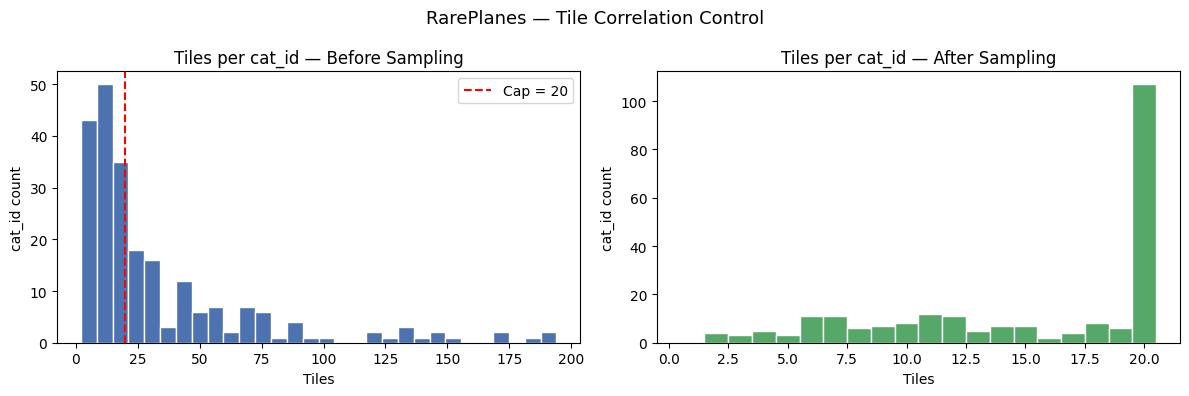

In [5]:
rng = random.Random(SEED)

# Group tile_ids by satellite image (cat_id)
catid_to_tiles = defaultdict(list)
for tile_id, rec in rp_tile_records.items():
    catid_to_tiles[rec['cat_id']].append(tile_id)

# Sample up to MAX_TILES_PER_CATID per cat_id
rp_sampled = set()
tiles_per_catid_after = []

for cat_id, tiles in catid_to_tiles.items():
    pool = tiles[:]
    rng.shuffle(pool)
    chosen = pool[:MAX_TILES_PER_CATID]
    rp_sampled.update(chosen)
    tiles_per_catid_after.append(len(chosen))

# Per-category counts after sampling
cat_counts_sampled = Counter()
for tile_id in rp_sampled:
    for ann in rp_tile_records[tile_id]['annotations']:
        cat_counts_sampled[ann['category_id']] += 1

print(f'Unique satellite images (cat_id): {len(catid_to_tiles)}')
print(f'Tiles before sampling           : {len(rp_tile_records):,}')
print(f'Tiles after sampling            : {len(rp_sampled):,}')
print(f'Mean tiles/cat_id after         : {sum(tiles_per_catid_after)/len(tiles_per_catid_after):.1f}')
print()
print('Annotations per category after sampling:')
for cat in CATEGORIES:
    n = cat_counts_sampled[cat['id']]
    print(f'  {cat["name"]:<22}: {n:,}')

# ── Visualise tiles-per-cat_id distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = [len(t) for t in catid_to_tiles.values()]
axes[0].hist(before, bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(MAX_TILES_PER_CATID, color='red', linestyle='--', label=f'Cap = {MAX_TILES_PER_CATID}')
axes[0].set_title('Tiles per cat_id — Before Sampling')
axes[0].set_xlabel('Tiles')
axes[0].set_ylabel('cat_id count')
axes[0].legend()

axes[1].hist(tiles_per_catid_after, bins=range(1, MAX_TILES_PER_CATID + 2),
             color='#55A868', edgecolor='white', align='left')
axes[1].set_title('Tiles per cat_id — After Sampling')
axes[1].set_xlabel('Tiles')
axes[1].set_ylabel('cat_id count')

plt.suptitle('RarePlanes — Tile Correlation Control', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# ── Copy sampled RarePlanes tiles to the output images directory ───────────────
# Tiles are already 512×512 PNG; just copy with a 'rp_' prefix to avoid collisions.
print(f'Copying {len(rp_sampled):,} RarePlanes tiles → {OUT_IMAGES}...')

copied = skipped_existing = 0
for i, tile_id in enumerate(sorted(rp_sampled)):
    src = Path(rp_tile_records[tile_id]['img_path'])
    dst = OUT_IMAGES / f'rp_{tile_id}.png'
    if dst.exists():
        skipped_existing += 1
    else:
        shutil.copy2(src, dst)
        copied += 1
    if (i + 1) % 500 == 0:
        print(f'  {i + 1:,}/{len(rp_sampled):,} processed...')

print(f'Done — copied: {copied:,}, already existed: {skipped_existing:,}')

Copying 3,416 RarePlanes tiles → /Users/jonathan/Desktop/VoyagerTechnicalChallenge/data_prep/output/images...
  500/3,416 processed...
  1,000/3,416 processed...
  1,500/3,416 processed...
  2,000/3,416 processed...
  2,500/3,416 processed...
  3,000/3,416 processed...
Done — copied: 3,416, already existed: 0


---
## Step 2 — xView Preprocessing

**What this step does:**
- Loads `xView_train.geojson` and keeps only fixed-wing aircraft annotations (type_ids 11, 12, 13, 93)
- For each of the 239 images that contain at least one such aircraft:
  - Tiles the image into non-overlapping 512×512 patches (floor-divided, edge remainder discarded)
  - For each tile, finds annotations that overlap it with at least `XV_MIN_OVERLAP_FRAC` of their area inside
  - Clips retained annotation bboxes to tile-relative coordinates
  - Saves aircraft-containing tiles as RGB PNG files

> **Note on image format:** xView GeoTIFFs are 8-bit RGB — no normalisation needed before saving as PNG.

In [7]:
print('Loading xView GeoJSON and filtering to fixed-wing aircraft...')

with open(XVIEW_DIR / 'xView_train.geojson') as f:
    xv_raw = json.load(f)

# Group aircraft annotations by image_id
xv_img_anns = defaultdict(list)   # image_id → list of annotation dicts
type_counter = Counter()

for feat in xv_raw['features']:
    p   = feat['properties']
    tid = p['type_id']
    if tid not in XV_AIRCRAFT_IDS:
        continue
    x0, y0, x1, y1 = (int(v) for v in p['bounds_imcoords'].split(','))
    area = bbox_area(x0, y0, x1, y1)
    if area < MIN_BBOX_AREA_PX:
        continue
    xv_img_anns[p['image_id']].append({
        'type_id':     tid,
        'category_id': XV_TYPE_TO_CAT[tid],
        'x0': x0, 'y0': y0, 'x1': x1, 'y1': y1,
        'area': area,
    })
    type_counter[tid] += 1

TYPE_NAMES = {11: 'Fixed-wing Aircraft', 12: 'Small Aircraft',
              13: 'Cargo Plane',         93: 'Fixed-wing (variant)'}

print(f'Images with fixed-wing aircraft : {len(xv_img_anns)}')
print(f'Total aircraft annotations      : {sum(type_counter.values()):,}')
print()
print('By type_id:')
for tid in sorted(XV_AIRCRAFT_IDS):
    cat_name = CAT_ID_TO_NAME[XV_TYPE_TO_CAT[tid]]
    print(f'  {tid} ({TYPE_NAMES[tid]:<26}) → {cat_name:<20}: {type_counter[tid]:,}')

Loading xView GeoJSON and filtering to fixed-wing aircraft...
Images with fixed-wing aircraft : 239
Total aircraft annotations      : 1,534

By type_id:
  11 (Fixed-wing Aircraft       ) → medium_aircraft     : 74
  12 (Small Aircraft            ) → small_aircraft      : 368
  13 (Cargo Plane               ) → large_aircraft      : 718
  93 (Fixed-wing (variant)      ) → medium_aircraft     : 374


In [8]:
print('Tiling xView images → 512×512 PNG patches...')
print('(Reads ~239 GeoTIFFs; expect 2–5 minutes on first run)\n')

# xv_tile_records: tile_id → {img_path, image_id, annotations}
xv_tile_records = {}
total_imgs = len(xv_img_anns)

for img_idx, (img_id, anns) in enumerate(sorted(xv_img_anns.items())):
    img_path = XVIEW_DIR / 'train_images' / img_id
    if not img_path.exists():
        continue

    img = Image.open(img_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    W, H = img.size

    n_cols = W // TILE_SIZE
    n_rows = H // TILE_SIZE
    img_stem = img_id.replace('.tif', '')
    tiles_this_img = 0

    for r in range(n_rows):
        for c in range(n_cols):
            tx0 = c * TILE_SIZE
            ty0 = r * TILE_SIZE
            tx1 = tx0 + TILE_SIZE
            ty1 = ty0 + TILE_SIZE

            tile_anns = []
            for ann in anns:
                # Intersection of annotation bbox and tile window
                ix0 = max(ann['x0'], tx0)
                iy0 = max(ann['y0'], ty0)
                ix1 = min(ann['x1'], tx1)
                iy1 = min(ann['y1'], ty1)

                if ix1 <= ix0 or iy1 <= iy0:
                    continue   # no overlap

                overlap_area = bbox_area(ix0, iy0, ix1, iy1)
                if overlap_area / max(ann['area'], 1) < XV_MIN_OVERLAP_FRAC:
                    continue   # annotation mostly outside this tile

                # Tile-relative clipped coordinates
                cx0, cy0, cx1, cy1 = ix0 - tx0, iy0 - ty0, ix1 - tx0, iy1 - ty0
                clipped_area = bbox_area(cx0, cy0, cx1, cy1)
                if clipped_area < MIN_BBOX_AREA_PX:
                    continue

                tile_anns.append({
                    'category_id': ann['category_id'],
                    'type_id':     ann['type_id'],
                    'bbox':        to_coco_bbox(cx0, cy0, cx1, cy1),
                    'area':        clipped_area,
                })

            if not tile_anns:
                continue

            # Crop and save tile (skip if already exists from a prior run)
            tile_id  = f'xv_{img_stem}_r{r}_c{c}'
            out_path = OUT_IMAGES / f'{tile_id}.png'
            if not out_path.exists():
                img.crop((tx0, ty0, tx1, ty1)).save(out_path)

            xv_tile_records[tile_id] = {
                'img_path':    str(out_path),
                'image_id':    img_id,
                'annotations': tile_anns,
            }
            tiles_this_img += 1

    img.close()

    if (img_idx + 1) % 30 == 0 or img_idx == total_imgs - 1:
        print(f'  [{img_idx+1}/{total_imgs}] {img_id:<16} '
              f'{tiles_this_img} aircraft tiles  |  cumulative: {len(xv_tile_records):,}')

# ── Summary ───────────────────────────────────────────────────────────────────
xv_cat_counts = Counter()
for rec in xv_tile_records.values():
    for ann in rec['annotations']:
        xv_cat_counts[ann['category_id']] += 1

print(f'\nxView tiling complete.')
print(f'Aircraft tiles saved : {len(xv_tile_records):,}')
print('Annotations per category:')
for cat in CATEGORIES:
    print(f'  {cat["name"]:<22}: {xv_cat_counts[cat["id"]]:,}')

Tiling xView images → 512×512 PNG patches...
(Reads ~239 GeoTIFFs; expect 2–5 minutes on first run)

  [30/239] 129.tif          1 aircraft tiles  |  cumulative: 101
  [60/239] 1703.tif         6 aircraft tiles  |  cumulative: 194
  [90/239] 2114.tif         2 aircraft tiles  |  cumulative: 279
  [120/239] 2355.tif         1 aircraft tiles  |  cumulative: 369
  [150/239] 295.tif          5 aircraft tiles  |  cumulative: 468
  [180/239] 517.tif          1 aircraft tiles  |  cumulative: 544
  [210/239] 716.tif          1 aircraft tiles  |  cumulative: 657
  [239/239] 996.tif          2 aircraft tiles  |  cumulative: 730

xView tiling complete.
Aircraft tiles saved : 730
Annotations per category:
  small_aircraft        : 330
  medium_aircraft       : 405
  large_aircraft        : 693
  military_aircraft     : 0


---
## Step 3 — Balanced Subset & Train/Val Split

**Class balance strategy:**
- Each tile is assigned its *dominant* category (the class with the most annotations in that tile)
- Tiles are pooled per category across both datasets
- The subset samples up to `target_per_cat = SUBSET_SIZE // 4` tiles per category, preferring a ~70/30 RarePlanes/xView mix when both are available
- If a category has fewer tiles than the target, all available tiles are taken

**Leakage-free split:**
- RarePlanes: train/val assignment is made at the `cat_id` (satellite image) level — all tiles from a given satellite pass go to the same split
- xView: assignment is made at the `image_id` level — all tiles from a given source image go to the same split

In [9]:
def dominant_category(annotations):
    """Return the category_id that appears most in the annotation list."""
    return Counter(a['category_id'] for a in annotations).most_common(1)[0][0]


# ── Pool tiles by dominant category ───────────────────────────────────────────
rp_by_cat = defaultdict(list)
for tile_id in rp_sampled:
    dc = dominant_category(rp_tile_records[tile_id]['annotations'])
    rp_by_cat[dc].append(tile_id)

xv_by_cat = defaultdict(list)
for tile_id, rec in xv_tile_records.items():
    dc = dominant_category(rec['annotations'])
    xv_by_cat[dc].append(tile_id)

print('Available tiles per category (before subsetting):')
for cat in CATEGORIES:
    cid = cat['id']
    print(f'  {cat["name"]:<22}: RP={len(rp_by_cat[cid]):<5}  XV={len(xv_by_cat[cid]):<5}  '
          f'total={len(rp_by_cat[cid]) + len(xv_by_cat[cid])}')

# ── Sample balanced subset ────────────────────────────────────────────────────
rng_sub       = random.Random(SEED)
target_per_cat = SUBSET_SIZE // len(CATEGORIES)
subset_rp, subset_xv = set(), set()

print(f'\nTarget tiles per category: {target_per_cat}')
print('Sampling (prefer ~70% RP / 30% XV when both available):')

for cat in CATEGORIES:
    cid      = cat['id']
    rp_pool  = rp_by_cat[cid][:]
    xv_pool  = xv_by_cat[cid][:]
    rng_sub.shuffle(rp_pool)
    rng_sub.shuffle(xv_pool)

    available = len(rp_pool) + len(xv_pool)
    n_take    = min(target_per_cat, available)

    # Compute split: prefer 70% RP, fill remainder with XV (or vice-versa if short)
    n_rp = min(len(rp_pool), round(n_take * 0.70))
    n_xv = min(len(xv_pool), n_take - n_rp)
    n_rp = min(len(rp_pool), n_take - n_xv)   # re-clamp if xv was short

    subset_rp.update(rp_pool[:n_rp])
    subset_xv.update(xv_pool[:n_xv])

    print(f'  {cat["name"]:<22}: target={target_per_cat}  '
          f'took RP={n_rp}, XV={n_xv}  '
          f'(available: RP={len(rp_pool)}, XV={len(xv_pool)})')

total_subset = len(subset_rp) + len(subset_xv)
print(f'\nSubset total: {len(subset_rp)} RP + {len(subset_xv)} XV = {total_subset} tiles')

Available tiles per category (before subsetting):
  small_aircraft        : RP=1735   XV=79     total=1814
  medium_aircraft       : RP=1324   XV=293    total=1617
  large_aircraft        : RP=247    XV=358    total=605
  military_aircraft     : RP=110    XV=0      total=110

Target tiles per category: 250
Sampling (prefer ~70% RP / 30% XV when both available):
  small_aircraft        : target=250  took RP=175, XV=75  (available: RP=1735, XV=79)
  medium_aircraft       : target=250  took RP=175, XV=75  (available: RP=1324, XV=293)
  large_aircraft        : target=250  took RP=175, XV=75  (available: RP=247, XV=358)
  military_aircraft     : target=250  took RP=110, XV=0  (available: RP=110, XV=0)

Subset total: 635 RP + 225 XV = 860 tiles


In [10]:
# ── Train/val split — grouped by source image to prevent leakage ──────────────
rng_split = random.Random(SEED + 1)

def group_split(tile_ids_rp, tile_ids_xv, train_ratio):
    """Split tiles into train/val by assigning each *source group* (cat_id for RP,
    image_id for XV) to one split. All tiles from a group stay together."""

    # RarePlanes — group by cat_id
    rp_groups = defaultdict(list)
    for tid in tile_ids_rp:
        rp_groups[rp_tile_records[tid]['cat_id']].append(tid)

    rp_gids = sorted(rp_groups)
    rng_split.shuffle(rp_gids)
    n_train_rp   = max(1, round(len(rp_gids) * train_ratio))
    train_rp_gids = set(rp_gids[:n_train_rp])

    rp_train = {tid for gid in train_rp_gids for tid in rp_groups[gid]}
    rp_val   = set(tile_ids_rp) - rp_train

    # xView — group by image_id
    xv_groups = defaultdict(list)
    for tid in tile_ids_xv:
        xv_groups[xv_tile_records[tid]['image_id']].append(tid)

    xv_gids = sorted(xv_groups)
    rng_split.shuffle(xv_gids)
    n_train_xv   = max(1, round(len(xv_gids) * train_ratio))
    train_xv_gids = set(xv_gids[:n_train_xv])

    xv_train = {tid for gid in train_xv_gids for tid in xv_groups[gid]}
    xv_val   = set(tile_ids_xv) - xv_train

    return rp_train, rp_val, xv_train, xv_val


rp_train, rp_val, xv_train, xv_val = group_split(subset_rp, subset_xv, TRAIN_RATIO)

n_train = len(rp_train) + len(xv_train)
n_val   = len(rp_val)   + len(xv_val)
print(f'Train: {len(rp_train)} RP + {len(xv_train)} XV = {n_train} tiles  ({n_train/total_subset:.1%})')
print(f'Val  : {len(rp_val)}  RP + {len(xv_val)}  XV = {n_val} tiles  ({n_val/total_subset:.1%})')

# Confirm no source-group leakage
rp_train_cats = {rp_tile_records[t]['cat_id'] for t in rp_train}
rp_val_cats   = {rp_tile_records[t]['cat_id'] for t in rp_val}
xv_train_imgs = {xv_tile_records[t]['image_id'] for t in xv_train}
xv_val_imgs   = {xv_tile_records[t]['image_id'] for t in xv_val}

rp_leak = rp_train_cats & rp_val_cats
xv_leak = xv_train_imgs & xv_val_imgs
print(f'\nLeakage check:')
print(f'  RarePlanes cat_id overlap  : {len(rp_leak)}  (should be 0)')
print(f'  xView image_id overlap     : {len(xv_leak)}  (should be 0)')

Train: 531 RP + 183 XV = 714 tiles  (83.0%)
Val  : 104  RP + 42  XV = 146 tiles  (17.0%)

Leakage check:
  RarePlanes cat_id overlap  : 0  (should be 0)
  xView image_id overlap     : 0  (should be 0)


---
## Step 4 — Save Outputs

Generates four COCO JSON annotation files:

| File | Contents |
|---|---|
| `dataset_full.json` | All sampled RP tiles + all xView aircraft tiles |
| `dataset_subset.json` | Balanced subset (train + val combined) |
| `train.json` | Training split of the subset |
| `val.json` | Validation split of the subset |

In [11]:
coco_full   = build_coco_dataset(rp_sampled,  set(xv_tile_records), 'full')
coco_subset = build_coco_dataset(subset_rp,   subset_xv,            'subset')
coco_train  = build_coco_dataset(rp_train,    xv_train,             'train')
coco_val    = build_coco_dataset(rp_val,      xv_val,               'val')

for name, coco in [('dataset_full',   coco_full),
                   ('dataset_subset', coco_subset),
                   ('train',          coco_train),
                   ('val',            coco_val)]:
    out_path = OUT_ANNOTS / f'{name}.json'
    with open(out_path, 'w') as f:
        json.dump(coco, f, indent=2)
    print(f'Saved {name}.json  '
          f'— images: {len(coco["images"]):,}  '
          f'annotations: {len(coco["annotations"]):,}')

# ── Preprocessing log ─────────────────────────────────────────────────────────
log = {
    'config': {
        'tile_size':           TILE_SIZE,
        'min_bbox_area_px':    MIN_BBOX_AREA_PX,
        'rp_min_partial_dec':  RP_MIN_PARTIAL_DEC,
        'max_tiles_per_catid': MAX_TILES_PER_CATID,
        'xv_min_overlap_frac': XV_MIN_OVERLAP_FRAC,
        'subset_size':         SUBSET_SIZE,
        'train_ratio':         TRAIN_RATIO,
        'seed':                SEED,
    },
    'rareplanes': {
        'tiles_with_annotations':     len(rp_tile_records),
        'unique_cat_ids':             len(catid_to_tiles),
        'tiles_after_catid_sampling': len(rp_sampled),
    },
    'xview': {
        'images_with_aircraft':   len(xv_img_anns),
        'aircraft_tiles_produced': len(xv_tile_records),
        'aircraft_type_ids':      sorted(XV_AIRCRAFT_IDS),
    },
    'subset': {
        'total': total_subset,
        'train': n_train,
        'val':   n_val,
    },
    'category_mapping': {
        'rareplanes': RP_ROLE_TO_CAT,
        'xview':      {str(k): v for k, v in XV_TYPE_TO_CAT.items()},
    },
}
with open(OUT_DIR / 'preprocessing_log.json', 'w') as f:
    json.dump(log, f, indent=2)
print('\nSaved preprocessing_log.json')

# ── Verify all subset image files exist on disk ────────────────────────────────
missing = []
for img_info in coco_subset['images']:
    p = OUT_IMAGES / img_info['file_name']
    if not p.exists():
        missing.append(img_info['file_name'])

if missing:
    print(f'\nWARNING — {len(missing)} subset images missing from disk:')
    for fn in missing[:10]:
        print(f'  {fn}')
else:
    print(f'\nFile check: all {len(coco_subset["images"])} subset images present on disk.')

Saved dataset_full.json  — images: 4,146  annotations: 12,238
Saved dataset_subset.json  — images: 860  annotations: 2,063
Saved train.json  — images: 714  annotations: 1,666
Saved val.json  — images: 146  annotations: 397

Saved preprocessing_log.json

File check: all 860 subset images present on disk.


---
## Step 5 — Verification & Visualisation

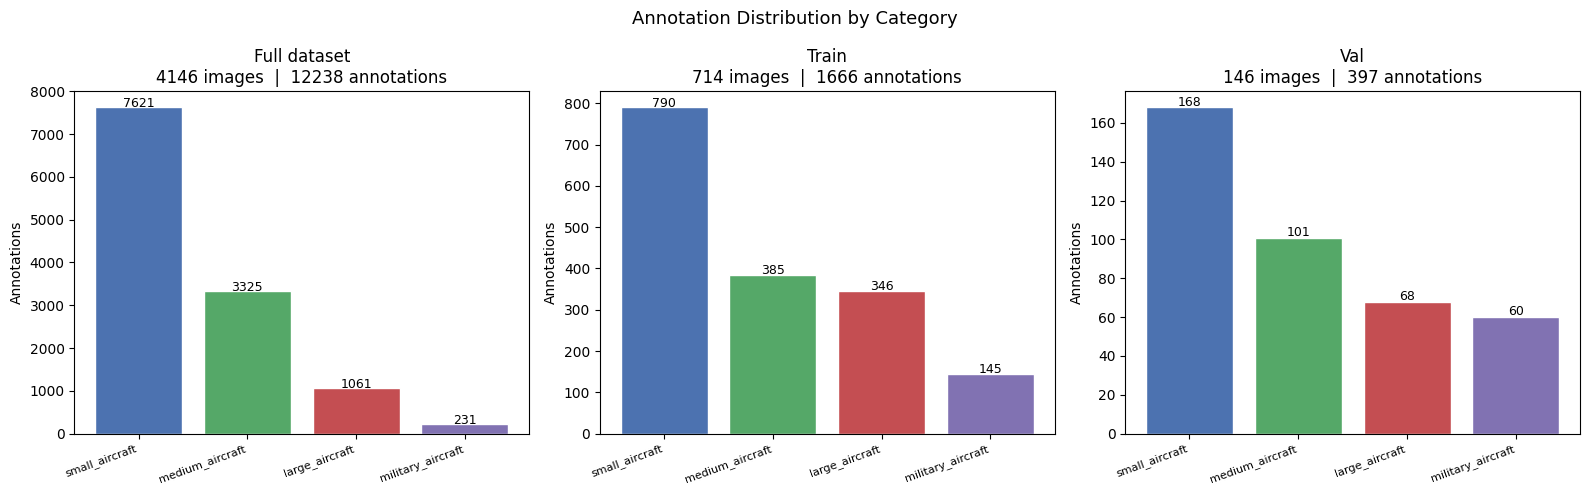

Source breakdown:
  Full dataset  : RarePlanes=3416   xView=730    total=4146
  Train         : RarePlanes=531    xView=183    total=714
  Val           : RarePlanes=104    xView=42     total=146


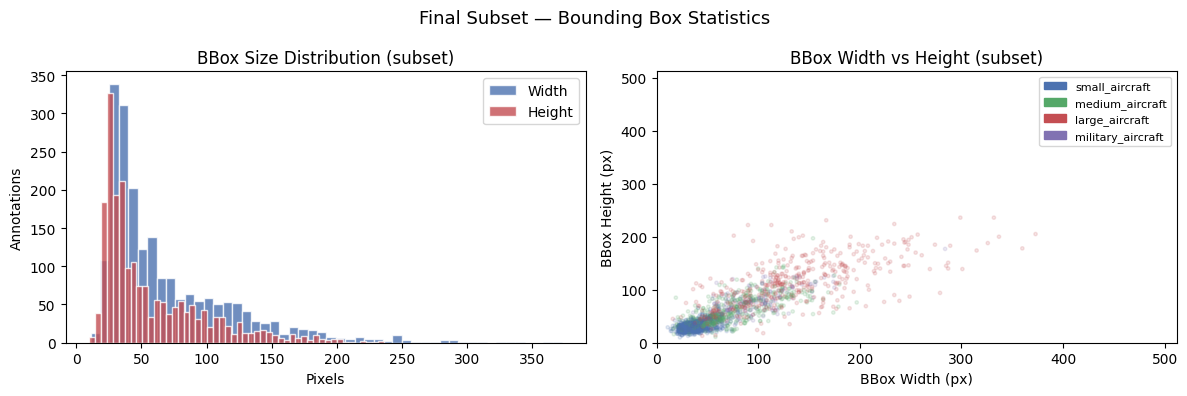


BBox width  — min:11  max:373  mean:70.5
BBox height — min:10  max:236  mean:57.6


In [12]:
# ── Annotation distribution per split and source ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

splits = [('Full dataset', coco_full), ('Train', coco_train), ('Val', coco_val)]
for ax, (title, coco) in zip(axes, splits):
    cnt = Counter(a['category_id'] for a in coco['annotations'])
    names  = [CAT_ID_TO_NAME[cid] for cid in sorted(cnt)]
    values = [cnt[cid] for cid in sorted(cnt)]
    colors = [CAT_COLORS[cid] for cid in sorted(cnt)]
    bars = ax.bar(names, values, color=colors, edgecolor='white')
    ax.set_title(f'{title}\n{len(coco["images"])} images  |  {len(coco["annotations"])} annotations')
    ax.set_ylabel('Annotations')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=9)

plt.suptitle('Annotation Distribution by Category', fontsize=13)
plt.tight_layout()
plt.show()

# ── Source breakdown ───────────────────────────────────────────────────────────
print('Source breakdown:')
for title, coco in splits:
    rp_n = sum(1 for img in coco['images'] if img['source'] == 'rareplanes')
    xv_n = sum(1 for img in coco['images'] if img['source'] == 'xview')
    print(f'  {title:<14}: RarePlanes={rp_n:<5}  xView={xv_n:<5}  total={rp_n+xv_n}')

# ── Bbox size distribution in final subset ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
widths  = [ann['bbox'][2] for ann in coco_subset['annotations']]
heights = [ann['bbox'][3] for ann in coco_subset['annotations']]

axes[0].hist(widths,  bins=50, color='#4C72B0', edgecolor='white', alpha=0.8, label='Width')
axes[0].hist(heights, bins=50, color='#C44E52', edgecolor='white', alpha=0.8, label='Height')
axes[0].set_title('BBox Size Distribution (subset)')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Annotations')
axes[0].legend()

axes[1].scatter(widths, heights, alpha=0.15, s=6,
                c=[CAT_COLORS[a['category_id']] for a in coco_subset['annotations']])
axes[1].set_xlim(0, TILE_SIZE)
axes[1].set_ylim(0, TILE_SIZE)
axes[1].set_xlabel('BBox Width (px)')
axes[1].set_ylabel('BBox Height (px)')
axes[1].set_title('BBox Width vs Height (subset)')
legend_handles = [mpatches.Patch(color=CAT_COLORS[c['id']], label=c['name']) for c in CATEGORIES]
axes[1].legend(handles=legend_handles, fontsize=8, markerscale=2)

plt.suptitle('Final Subset — Bounding Box Statistics', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nBBox width  — min:{min(widths)}  max:{max(widths)}  mean:{sum(widths)/len(widths):.1f}')
print(f'BBox height — min:{min(heights)}  max:{max(heights)}  mean:{sum(heights)/len(heights):.1f}')

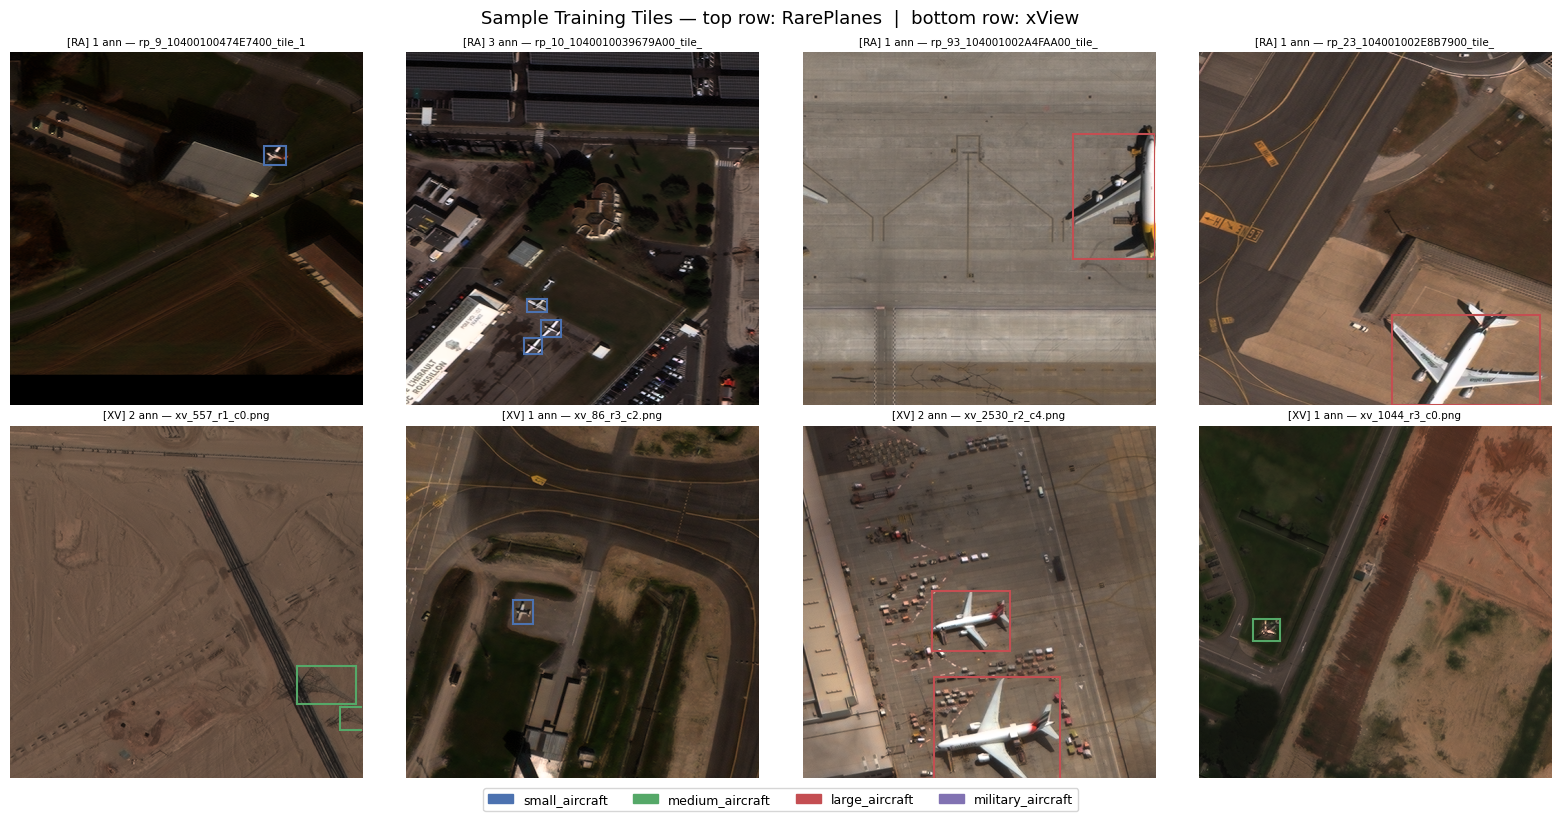

In [13]:
# ── Sample tile grid: 4 RP + 4 XV tiles from train split ─────────────────────
rng_vis = random.Random(SEED + 99)

def sample_tiles_from_coco(coco, source, n):
    """Return n randomly sampled image dicts from a given source."""
    pool = [img for img in coco['images'] if img['source'] == source]
    return rng_vis.sample(pool, min(n, len(pool)))

id_to_anns_train = defaultdict(list)
for ann in coco_train['annotations']:
    id_to_anns_train[ann['image_id']].append(ann)

samples_rp = sample_tiles_from_coco(coco_train, 'rareplanes', 4)
samples_xv = sample_tiles_from_coco(coco_train, 'xview',      4)
all_samples = samples_rp + samples_xv

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, img_info in zip(axes, all_samples):
    img_path = OUT_IMAGES / img_info['file_name']
    if not img_path.exists():
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue

    img = np.array(Image.open(img_path))
    ax.imshow(img)

    for ann in id_to_anns_train[img_info['id']]:
        x, y, w, h = ann['bbox']
        rect = mpatches.Rectangle(
            (x, y), w, h,
            linewidth=1.5,
            edgecolor=CAT_COLORS.get(ann['category_id'], 'yellow'),
            facecolor='none'
        )
        ax.add_patch(rect)

    src   = img_info['source']
    n_ann = len(id_to_anns_train[img_info['id']])
    ax.set_title(f'[{src[:2].upper()}] {n_ann} ann — {img_info["file_name"][:28]}',
                 fontsize=7.5)
    ax.axis('off')

legend_handles = [mpatches.Patch(color=CAT_COLORS[c['id']], label=c['name']) for c in CATEGORIES]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
plt.suptitle('Sample Training Tiles — top row: RarePlanes  |  bottom row: xView', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# ── Final summary printout ────────────────────────────────────────────────────
print('=' * 62)
print('PREPROCESSING COMPLETE')
print('=' * 62)
print(f'Output directory : {OUT_DIR}')
print()
print('Images on disk:')
n_rp_imgs = sum(1 for f in OUT_IMAGES.iterdir() if f.name.startswith('rp_'))
n_xv_imgs = sum(1 for f in OUT_IMAGES.iterdir() if f.name.startswith('xv_'))
print(f'  RarePlanes tiles : {n_rp_imgs:,}')
print(f'  xView tiles      : {n_xv_imgs:,}')
print(f'  Total            : {n_rp_imgs + n_xv_imgs:,}')
print()
print('Annotation files (COCO format):')
for name, coco in [('dataset_full',   coco_full),
                   ('dataset_subset', coco_subset),
                   ('train',          coco_train),
                   ('val',            coco_val)]:
    print(f'  {name+".json":<25}: {len(coco["images"]):>5} images  '
          f'{len(coco["annotations"]):>6} annotations')
print()
print('Category IDs in COCO files:')
for cat in CATEGORIES:
    print(f'  {cat["id"]} = {cat["name"]}')

PREPROCESSING COMPLETE
Output directory : /Users/jonathan/Desktop/VoyagerTechnicalChallenge/data_prep/output

Images on disk:
  RarePlanes tiles : 3,416
  xView tiles      : 730
  Total            : 4,146

Annotation files (COCO format):
  dataset_full.json        :  4146 images   12238 annotations
  dataset_subset.json      :   860 images    2063 annotations
  train.json               :   714 images    1666 annotations
  val.json                 :   146 images     397 annotations

Category IDs in COCO files:
  1 = small_aircraft
  2 = medium_aircraft
  3 = large_aircraft
  4 = military_aircraft
